In [1]:
!pip install vaderSentiment transformers wordcloud --quiet


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip


In [2]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import re, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from supabase import create_client, Client

/Users/deepikadasari/Documents/Abhi/SCU/ClubsProjectsResearch/Research/ProfGhoshResearch/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
#Sentiment analysis function
def sentiment_scores(sentence):
    sid_obj = SentimentIntensityAnalyzer()
    sentiment_dict = sid_obj.polarity_scores(sentence)

    print(f"Sentiment Scores: {sentiment_dict}")
    print(f"Negative Sentiment: {sentiment_dict['neg']*100}%")
    print(f"Neutral Sentiment: {sentiment_dict['neu']*100}%")
    print(f"Positive Sentiment: {sentiment_dict['pos']*100}%")
    print(f"Overall Sentiment: ", end="")

In [ ]:
#Getting the youtube comments
# ── 3. Fetch ALL rows from Supabase (paginated) ───────────────────────────────

supabase: Client = create_client(SUPABASE_URL, SUPABASE_KEY)

PAGE_SIZE = 1000
all_rows  = []
page      = 0

print("Fetching all rows from Supabase ...")
while True:
    start = page * PAGE_SIZE
    end   = start + PAGE_SIZE - 1
    resp  = (
        supabase.table("YoutubeCommentswTimestamp")
        .select("id, video_id, Video_title, Comment_Timestamp, Comment")
        .range(start, end)
        .execute()
    )
    batch = resp.data
    if not batch:
        break
    all_rows.extend(batch)
    print(f"  page {page+1}: fetched {len(batch)} rows  (total so far: {len(all_rows)})")
    if len(batch) < PAGE_SIZE:
        break
    page += 1

raw_df = pd.DataFrame(all_rows)
print(f"\nTotal rows fetched: {len(raw_df)}")
print(raw_df.dtypes)
raw_df.head()

Fetching all rows from Supabase ...
  page 1: fetched 1000 rows  (total so far: 1000)
  page 2: fetched 1000 rows  (total so far: 2000)
  page 3: fetched 1000 rows  (total so far: 3000)
  page 4: fetched 1000 rows  (total so far: 4000)
  page 5: fetched 1000 rows  (total so far: 5000)
  page 6: fetched 1000 rows  (total so far: 6000)
  page 7: fetched 1000 rows  (total so far: 7000)
  page 8: fetched 1000 rows  (total so far: 8000)
  page 9: fetched 1000 rows  (total so far: 9000)
  page 10: fetched 1000 rows  (total so far: 10000)

Total rows fetched: 10000
id                   int64
video_id               str
Video_title            str
Comment_Timestamp      str
Comment                str
dtype: object


,id,video_id,Video_title,Comment_Timestamp,Comment
0,1,fH_mfeKhTbU,AI Therapy Exposed: Clinical Psychologist Revi...,2026-02-28T19:47:48Z,"<a href=""https://www.youtube.com/watch?v=fH_mf..."
1,2,fH_mfeKhTbU,AI Therapy Exposed: Clinical Psychologist Revi...,2026-02-28T19:42:49Z,"<a href=""https://www.youtube.com/watch?v=fH_mf..."
2,3,fH_mfeKhTbU,AI Therapy Exposed: Clinical Psychologist Revi...,2026-02-15T14:31:53Z,I&#39;m not sure how many people talk to their...
3,4,fH_mfeKhTbU,AI Therapy Exposed: Clinical Psychologist Revi...,2026-02-09T09:40:30Z,Feelheard app is ai that listen to you reply w...
4,5,fH_mfeKhTbU,AI Therapy Exposed: Clinical Psychologist Revi...,2026-01-28T13:47:03Z,I tried AI and a regular therapist. I didn’t ...


In [5]:
#data cleaning
# ── 4. Clean & filter ─────────────────────────────────────────────────────────

#Something copilot added to filter out emojis and useless comments
EMOJI_RE    = re.compile(
    "["
    "\U0001F600-\U0001FFFF"   # emoticons
    "\U00002700-\U000027BF"   # dingbats
    "\U0001F300-\U0001F5FF"   # symbols & pictographs
    "\U0001F900-\U0001F9FF"   # supplemental symbols
    "\U0001FA00-\U0001FA6F"   # chess, etc.
    "\U00002600-\U000026FF"   # misc symbols
    "]+", flags=re.UNICODE
)
URL_RE      = re.compile(r'https?://\S+|www\.\S+', re.IGNORECASE)
HANDLE_RE   = re.compile(r'@\w+')

def is_useless(text: str) -> bool:
    """Return True if the comment should be discarded."""
    if not isinstance(text, str):
        return True
    stripped = text.strip()
    # Too short
    if len(stripped) < 10:
        return True
    # After stripping emojis, URLs, handles and punctuation — nothing left?
    cleaned = EMOJI_RE.sub('', stripped)
    cleaned = URL_RE.sub('', cleaned)
    cleaned = HANDLE_RE.sub('', cleaned)
    cleaned = re.sub(r'[^\w\s]', '', cleaned).strip()
    if len(cleaned) < 5:
        return True
    # All digits / numbers only
    if re.fullmatch(r'[\d\s]+', cleaned):
        return True
    return False

df = raw_df.copy()
df['Comment'] = df['Comment'].astype(str).str.strip()

before = len(df)
df = df[~df['Comment'].apply(is_useless)]
df = df.drop_duplicates(subset=['Comment'])
df = df.reset_index(drop=True)
after = len(df)

print(f"Rows before filtering : {before}")
print(f"Rows after  filtering : {after}  ({before - after} removed)")
df.head()

Rows before filtering : 10000
Rows after  filtering : 6561  (3439 removed)


,id,video_id,Video_title,Comment_Timestamp,Comment
0,1,fH_mfeKhTbU,AI Therapy Exposed: Clinical Psychologist Revi...,2026-02-28T19:47:48Z,"<a href=""https://www.youtube.com/watch?v=fH_mf..."
1,2,fH_mfeKhTbU,AI Therapy Exposed: Clinical Psychologist Revi...,2026-02-28T19:42:49Z,"<a href=""https://www.youtube.com/watch?v=fH_mf..."
2,3,fH_mfeKhTbU,AI Therapy Exposed: Clinical Psychologist Revi...,2026-02-15T14:31:53Z,I&#39;m not sure how many people talk to their...
3,4,fH_mfeKhTbU,AI Therapy Exposed: Clinical Psychologist Revi...,2026-02-09T09:40:30Z,Feelheard app is ai that listen to you reply w...
4,5,fH_mfeKhTbU,AI Therapy Exposed: Clinical Psychologist Revi...,2026-01-28T13:47:03Z,I tried AI and a regular therapist. I didn’t ...


In [6]:
#Vader sentiment analysis
# ── 5. Run VADER sentiment analysis ───────────────────────────────────────────
print("Running VADER sentiment analysis ...")
df['VADER_Sentiment'] = df['Comment'].apply(lambda x: SentimentIntensityAnalyzer().polarity_scores(x)['compound'])
print("Done.")
df.head()

for sentiment in ['Negative', 'Neutral', 'Positive']:
    subset = df[df['VADER_Sentiment'] < 0] if sentiment == 'Negative' else df[df['VADER_Sentiment'] == 0] if sentiment == 'Neutral' else df[df['VADER_Sentiment'] > 0]
    print(f"{sentiment} comments: {len(subset)}")

Running VADER sentiment analysis ...
Done.
Negative comments: 1766
Neutral comments: 1116
Positive comments: 3679


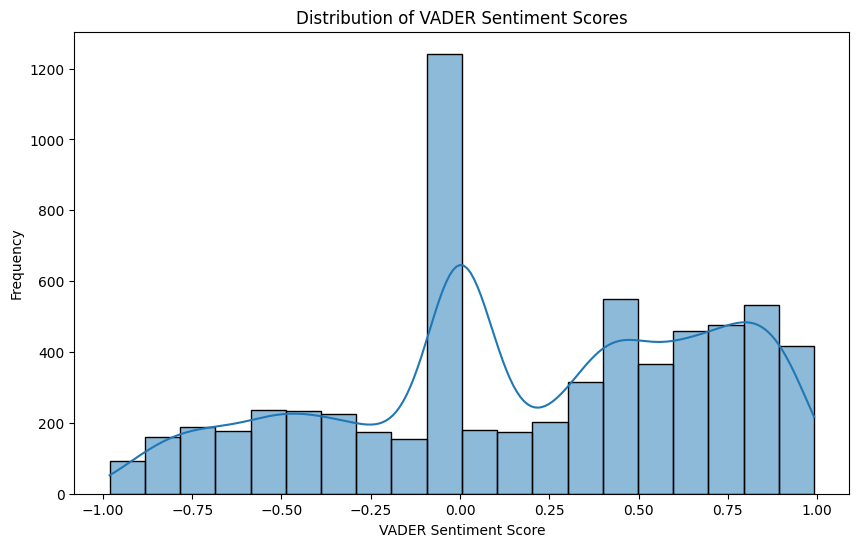

In [7]:
#Visualize the distribution of VADER sentiment scores
plt.figure(figsize=(10, 6))
sns.histplot(df['VADER_Sentiment'], bins=20, kde=True)
plt.title('Distribution of VADER Sentiment Scores')
plt.xlabel('VADER Sentiment Score')
plt.ylabel('Frequency')
plt.show()

### $NEXT UP WILL BE SENTIMENT OVER TIME

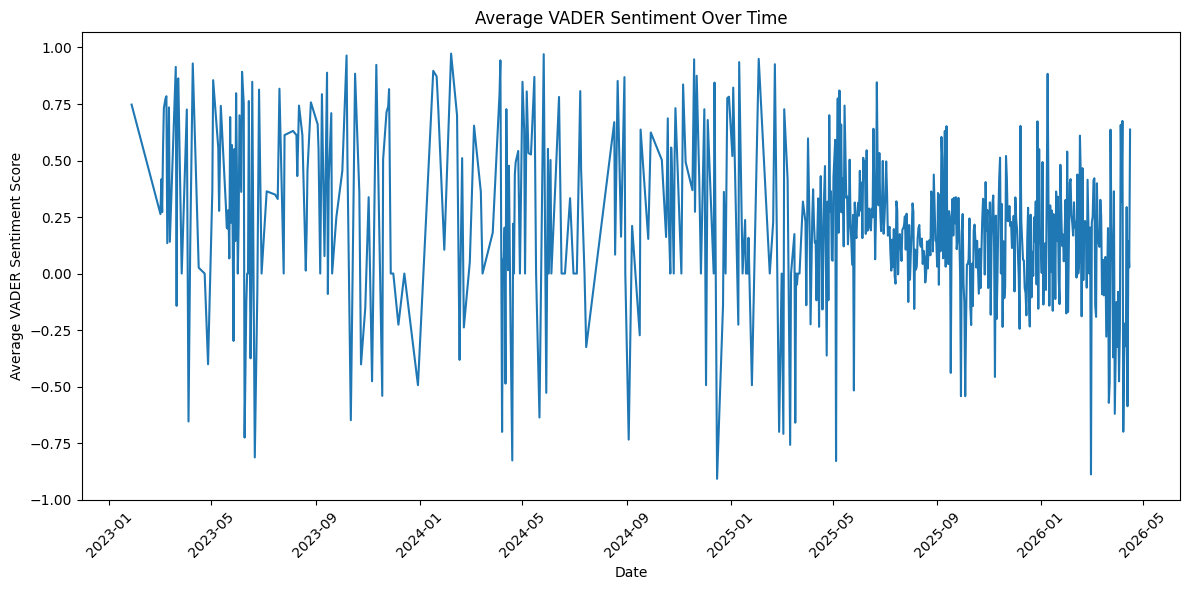

In [8]:
#Vader sentiment analysis over time visualization
df['Comment_Timestamp'] = pd.to_datetime(df['Comment_Timestamp'])
df['Date'] = df['Comment_Timestamp'].dt.date
daily_sentiment = df.groupby('Date')['VADER_Sentiment'].mean().reset_index()
plt.figure(figsize=(12, 6))
sns.lineplot(data=daily_sentiment, x='Date', y='VADER_Sentiment')
plt.title('Average VADER Sentiment Over Time')
plt.xlabel('Date')
plt.ylabel('Average VADER Sentiment Score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [9]:
# Vader sentinemtn analysis over time data display in a nice way 

# print("Average VADER sentiment per day:")
# print(daily_sentiment['VADER_Sentiment'].mean())

# print("VADER Sentiment states per month:")
# daily_sentiment['Month'] = pd.to_datetime(daily_sentiment['Date']).dt.to_period('M')
# monthly_sentiment = daily_sentiment.groupby('Month')['VADER_Sentiment'].mean().reset_index()
# print(monthly_sentiment)

#Classifying if overall sentiment is positive, negative or neutral based on the average VADER sentiment score
def classify_sentiment(score):
    if score > 0:
        return 'Positive'
    elif score < 0:
        return 'Negative'
    else:
        return 'Neutral'
daily_sentiment['Sentiment'] = daily_sentiment['VADER_Sentiment'].apply(classify_sentiment)
print("Daily sentiment classification:")
print(daily_sentiment[['Date', 'VADER_Sentiment', 'Sentiment']])

print("NNumber of positive, negative and neutral comments:")
print(daily_sentiment['Sentiment'].value_counts())


Daily sentiment classification:
           Date  VADER_Sentiment Sentiment
0    2023-01-27         0.747450  Positive
1    2023-03-02         0.262906  Positive
2    2023-03-03         0.416389  Positive
3    2023-03-04         0.271820  Positive
4    2023-03-05         0.550167  Positive
..          ...              ...       ...
612  2026-04-12         0.293925  Positive
613  2026-04-13        -0.586867  Negative
614  2026-04-14         0.144175  Positive
615  2026-04-15         0.027133  Positive
616  2026-04-16         0.636900  Positive

[617 rows x 3 columns]
NNumber of positive, negative and neutral comments:
Sentiment
Positive    445
Negative    125
Neutral      47
Name: count, dtype: int64
